In [1]:
import copy
from pathlib import Path

import gstools as gs
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import skfmm
from gstools import covmodel
from scipy.io import loadmat
from tqdm.auto import tqdm, trange

from nanopinv.prior import CholeskyPrior

# # ignore plot warnings in gstools
# import warnings
# warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset
M = loadmat("AM13_data.mat")
N_data, N_dim = M["S"].shape
sources = M["S"]  # Shape: (N_data, N_dim)
receivers = M["R"]  # Shape: (N_data, N_dim)
assert sources.shape == receivers.shape, (
    "Sources and receivers must have the same shape."
)

data_obs = M["d_obs"].flatten()
data_std = M["d_std"].flatten()
data_std = 0.4 * np.ones_like(
    data_obs
)  # For whatever reason, we overwrite this, maybe original data was wrong?

print(f"Number of data points: {N_data}")
print(f"Number of dimensions: {N_dim}")

Number of data points: 702
Number of dimensions: 2


c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\gstools\field\generator.py:237: UserWarning: gstools.RandMeth: **kwargs are ignored
  warnings.warn("gstools.RandMeth: **kwargs are ignored")


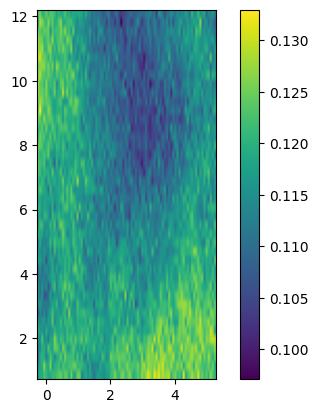

In [3]:
# Set up prior
dx = 0.135

x = np.arange(-2 * dx, 5 + 2 * dx, dx)
y = np.arange(1 - 2 * dx, 12 + 2 * dx, dx)
m0 = 0.12
C_m = covmodel.Spherical(dim=2, var=0.00003, len_scale=7)  # '0.00003 Sph(7)'

# Model parameters: Velocity field


srf = gs.SRF(C_m, mean=m0, generator_kwargs={"mode_no": 50})
samples = srf.structured((x, y))
# samples = srf((r[:, 0], r[:, 1]))

plt.imshow(samples, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis)
plt.colorbar()

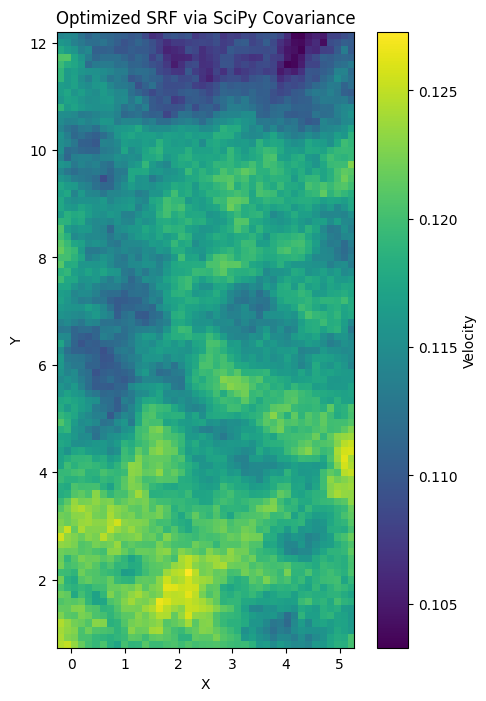

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from scipy import stats
from scipy.linalg import cholesky
from scipy.spatial.distance import pdist, squareform

# --- 1. Setup Parameters ---
dx = 0.135
x = np.arange(-2 * dx, 5 + 2 * dx, dx)
y = np.arange(1 - 2 * dx, 12 + 2 * dx, dx)

m0 = 0.12  # Mean
variance = 0.00003  # Variance
len_scale = 7.0  # Length scale

# --- 2. Create Coordinates & Distance Matrix ---
X, Y = np.meshgrid(x, y, indexing="ij")
points = np.column_stack([X.ravel(), Y.ravel()])

# OPTIMIZATION 1: pdist calculates only the unique pairs (2x faster than cdist)
# squareform unfolds it back into the symmetric NxN matrix
h = squareform(pdist(points))

# --- 3. Build the Spherical Covariance Matrix ---
cov_matrix = np.zeros_like(h)
mask = h <= len_scale
cov_matrix[mask] = variance * (
    1.0 - 1.5 * (h[mask] / len_scale) + 0.5 * (h[mask] ** 3 / len_scale**3)
)

# OPTIMIZATION 2: Fast in-place diagonal modification (much faster than np.eye)
nugget = 1e-10
np.fill_diagonal(cov_matrix, cov_matrix.diagonal() + nugget)

# --- 4. Store as SciPy Covariance Type ---
# OPTIMIZATION 3: Factorize once, store as a SciPy Covariance object.
# (Note: This requires SciPy 1.10.0 or newer)
L = cholesky(cov_matrix, lower=True)
scipy_cov = stats.Covariance.from_cholesky(L)

# --- 5. Generate the Random Field ---
mean_vec = np.full(len(points), m0)

# OPTIMIZATION 4: Pass the Covariance object to SciPy's stats module
# Because we pass 'scipy_cov', SciPy skips the heavy linear algebra!
mvn = stats.multivariate_normal(mean=mean_vec, cov=scipy_cov)

# Draw a sample (You can do samples_flat = mvn.rvs(size=10) to instantly get 10 fields)
samples_flat = mvn.rvs()

# Reshape back to the 2D grid shape (nx, ny)
samples = samples_flat.reshape((len(x), len(y)))

# --- 6. Plot the Results ---
plt.figure(figsize=(6, 8))
plt.imshow(
    samples.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(label="Velocity")
plt.title("Optimized SRF via SciPy Covariance")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

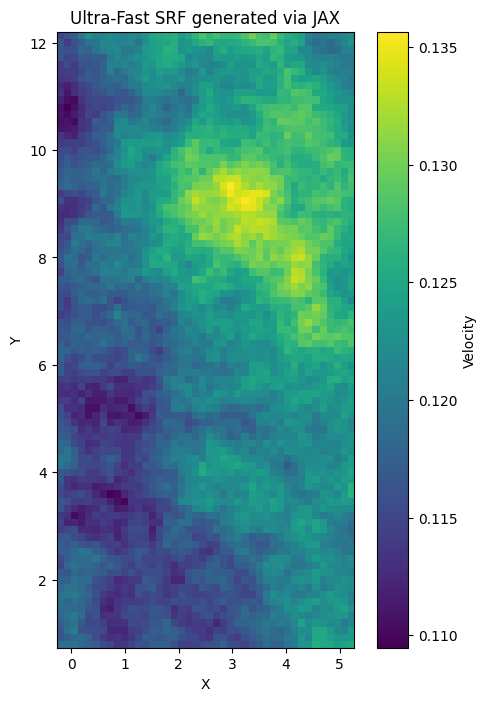

In [5]:
import jax

# MUST DO THIS FIRST: Covariance matrices require 64-bit precision to avoid Cholesky failing
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import jit, random
from matplotlib import cm

# ==========================================
# 1. JIT-Compiled JAX Functions
# ==========================================


@jit
def get_cholesky_factor(points, var, len_scale, nugget=1e-10):
    """Computes distances, spherical covariance, and Cholesky factor in one compiled pass."""
    # Compute pairwise distances (Vectorized in JAX)
    # diffs shape: (N, N, 2)
    diffs = points[:, None, :] - points[None, :, :]
    h = jnp.linalg.norm(diffs, axis=-1)

    # Calculate Spherical Covariance (using jnp.where for the h <= len_scale mask)
    cov_matrix = jnp.where(
        h <= len_scale,
        var * (1.0 - 1.5 * (h / len_scale) + 0.5 * (h / len_scale) ** 3),
        0.0,
    )

    # Add nugget to diagonal for numerical stability
    cov_matrix += jnp.eye(h.shape[0]) * nugget

    # Compute and return Cholesky decomposition (L)
    return jax.scipy.linalg.cholesky(cov_matrix, lower=True)


@jit
def sample_srf(L, mean_val, key):
    """Draws a random field using the pre-computed Cholesky factor L."""
    # Generate standard white noise
    z = random.normal(key, shape=(L.shape[0],))

    # Correlate the noise and add the mean
    return mean_val + L @ z


# ==========================================
# 2. Main Script
# ==========================================

# Setup Parameters
dx = 0.135
x = np.arange(-2 * dx, 5 + 2 * dx, dx)
y = np.arange(1 - 2 * dx, 12 + 2 * dx, dx)

m0 = 0.12
variance = 0.00003
len_scale = 7.0

# Create Coordinates (Convert to JAX arrays)
X, Y = np.meshgrid(x, y, indexing="ij")
points = jnp.array(np.column_stack([X.ravel(), Y.ravel()]))

# --- A. Setup the Model (Heavy Math) ---
# JAX compiles this on the first run. (Subsequent runs with same shapes are instantaneous).
L = get_cholesky_factor(points, var=variance, len_scale=len_scale)

# --- B. Generate Realizations (Instant Math) ---
# Initialize JAX random key
key = random.PRNGKey(42)

# Sample the field
samples_flat = sample_srf(L, m0, key)

# Reshape back to the 2D grid shape (nx, ny)
samples = np.array(samples_flat).reshape((len(x), len(y)))

# ==========================================
# 3. Plotting
# ==========================================
plt.figure(figsize=(6, 8))
plt.imshow(
    samples.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(label="Velocity")
plt.title("Ultra-Fast SRF generated via JAX")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [14]:
import time

import gstools as gs
import jax
import numpy as np
from scipy import stats
from scipy.linalg import cholesky
from scipy.spatial.distance import cdist, pdist, squareform

# MUST BE FIRST: Enable 64-bit precision for stable Cholesky decompositions
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import jit, random, vmap

# ==========================================
# 0. Setup Parameters & Grid
# ==========================================
dx = 0.135
x = np.arange(-2 * dx, 5 + 2 * dx, dx)
y = np.arange(1 - 2 * dx, 12 + 2 * dx, dx)

m0 = 0.12
variance = 0.00003
len_scale = 7.0
nugget = 1e-10
num_samples = 25  # How many realizations to draw after setup

# Create grid points
X, Y = np.meshgrid(x, y, indexing="ij")
points = np.column_stack([X.ravel(), Y.ravel()])
N = len(points)
print(f"Grid size: {len(x)} x {len(y)} = {N} total points.")
print(f"Covariance Matrix shape: {N} x {N}\n")


# ==========================================
# 1. Base NumPy Implementation (Exact)
# ==========================================
def bench_numpy():
    t0 = time.perf_counter()
    h = cdist(points, points)
    cov_matrix = np.zeros_like(h)
    mask = h <= len_scale
    cov_matrix[mask] = variance * (
        1.0 - 1.5 * (h[mask] / len_scale) + 0.5 * (h[mask] ** 3 / len_scale**3)
    )
    cov_matrix += np.eye(N) * nugget
    mean_vec = np.full(N, m0)
    t1 = time.perf_counter()

    for _ in range(num_samples):
        _ = np.random.multivariate_normal(mean=mean_vec, cov=cov_matrix)
    t2 = time.perf_counter()
    return t1 - t0, t2 - t1


# ==========================================
# 2. Optimized SciPy Implementation (Exact)
# ==========================================
def bench_scipy():
    t0 = time.perf_counter()
    h = squareform(pdist(points))
    cov_matrix = np.zeros_like(h)
    mask = h <= len_scale
    cov_matrix[mask] = variance * (
        1.0 - 1.5 * (h[mask] / len_scale) + 0.5 * (h[mask] ** 3 / len_scale**3)
    )
    np.fill_diagonal(cov_matrix, cov_matrix.diagonal() + nugget)

    L = cholesky(cov_matrix, lower=True)
    scipy_cov = stats.Covariance.from_cholesky(L)
    mean_vec = np.full(N, m0)
    mvn = stats.multivariate_normal(mean=mean_vec, cov=scipy_cov)
    t1 = time.perf_counter()

    for _ in range(num_samples):
        _ = mvn.rvs()
    t2 = time.perf_counter()
    return t1 - t0, t2 - t1


# ==========================================
# 3. JAX Implementation (Exact Batched Cholesky)
# ==========================================
@jit
def jax_setup_exact(pts, var, ls, nug):
    diffs = pts[:, None, :] - pts[None, :, :]
    h = jnp.linalg.norm(diffs, axis=-1)
    cov_matrix = jnp.where(
        h <= ls, var * (1.0 - 1.5 * (h / ls) + 0.5 * (h / ls) ** 3), 0.0
    )
    cov_matrix += jnp.eye(h.shape[0]) * nug
    return jax.scipy.linalg.cholesky(cov_matrix, lower=True)


# Define the base single-draw sample
def jax_sample_exact(L, mean_val, key):
    z = random.normal(key, shape=(L.shape[0],))
    return mean_val + L @ z


# Vmap it so JAX compiles the loop on the GPU/CPU hardware natively
@jit
def jax_sample_exact_batched(L, mean_val, batched_keys):
    return vmap(jax_sample_exact, in_axes=(None, None, 0))(L, mean_val, batched_keys)


def bench_jax_exact():
    pts_jax = jnp.array(points)

    t0 = time.perf_counter()
    L = jax_setup_exact(pts_jax, variance, len_scale, nugget)
    L.block_until_ready()
    t1 = time.perf_counter()

    # Pre-split seeds so we never dip back into Python loops during drawing
    key = random.PRNGKey(42)
    batched_keys = random.split(key, num_samples)

    samples = jax_sample_exact_batched(L, m0, batched_keys)
    samples.block_until_ready()

    t2 = time.perf_counter()
    return t1 - t0, t2 - t1


# ==========================================
# 4. JAX Implementation (Batched Approx - Sum of Cosines)
# ==========================================
@jit(static_argnames=["modes"])
def jax_sample_approx_batched(pts, mean_val, var, modes, batched_keys):

    def single_sample_approx(k):
        k_key, p_key = random.split(k)
        k_vecs = random.normal(k_key, shape=(2, modes))
        phases = random.uniform(p_key, shape=(modes,), minval=0.0, maxval=2 * jnp.pi)
        args = jnp.dot(pts, k_vecs) + phases
        srf = jnp.sum(jnp.cos(args), axis=1)
        return mean_val + jnp.sqrt(2.0 * var / modes) * srf

    return vmap(single_sample_approx, in_axes=(0))(batched_keys)


def bench_jax_approx():
    pts_jax = jnp.array(points)
    modes = 50

    t0 = time.perf_counter()
    t1 = time.perf_counter()

    key = random.PRNGKey(123)
    batched_keys = random.split(key, num_samples)

    samples = jax_sample_approx_batched(pts_jax, m0, variance, modes, batched_keys)
    samples.block_until_ready()

    t2 = time.perf_counter()
    return t1 - t0, t2 - t1


# ==========================================
# 5. GSTools (Default - No generator args)
# ==========================================
def bench_gstools_default():
    t0 = time.perf_counter()
    C_m = gs.Spherical(dim=2, var=variance, len_scale=len_scale)
    srf = gs.SRF(C_m, mean=m0)
    _ = srf.structured((x, y))  # Trigger lazy evaluation
    t1 = time.perf_counter()

    for _ in range(num_samples):
        _ = srf.structured((x, y))
    t2 = time.perf_counter()
    return t1 - t0, t2 - t1


# ==========================================
# 6. GSTools (Approx - mode_no=50)
# ==========================================
def bench_gstools_approx():
    t0 = time.perf_counter()
    C_m = gs.Spherical(dim=2, var=variance, len_scale=len_scale)
    srf = gs.SRF(C_m, mean=m0, generator_kwargs={"mode_no": 50})
    _ = srf.structured((x, y))
    t1 = time.perf_counter()

    for _ in range(num_samples):
        _ = srf.structured((x, y))
    t2 = time.perf_counter()
    return t1 - t0, t2 - t1


# ==========================================
# 7. GSTools (Exact - Cholesky)
# ==========================================
def bench_gstools_exact():
    t0 = time.perf_counter()
    C_m = gs.Spherical(dim=2, var=variance, len_scale=len_scale)
    srf = gs.SRF(C_m, mean=m0, generator="VelocityField")
    _ = srf.structured((x, y))
    t1 = time.perf_counter()

    for _ in range(num_samples):
        _ = srf.structured((x, y))
    t2 = time.perf_counter()
    return t1 - t0, t2 - t1


# ==========================================
# Run Benchmarks
# ==========================================

print("\n[Compiling JAX functions in the background...]")
# Warm up JAX so compilation time isn't included in the benchmark
_ = bench_jax_exact()
_ = bench_jax_approx()

print("-" * 65)
print(
    f"{'Method':<25} | {'Setup Time (s)':<15} | {f'Time for {num_samples} Samples (s)':<25}"
)
print("-" * 65)

# 1. NumPy
# time_np_setup, time_np_sample = bench_numpy()
# print(f"{'1. Base NumPy (Exact)':<25} | {time_np_setup:<15.4f} | {time_np_sample:<25.4f}")

# 2. SciPy
time_sp_setup, time_sp_sample = bench_scipy()
print(
    f"{'2. SciPy Opt. (Exact)':<25} | {time_sp_setup:<15.4f} | {time_sp_sample:<25.4f}"
)

# 3. JAX Exact
time_jax_setup, time_jax_sample = bench_jax_exact()
print(
    f"{'3. JAX (Exact Batched)':<25} | {time_jax_setup:<15.4f} | {time_jax_sample:<25.4f}"
)

# 4. JAX Approx
time_jax_ap_setup, time_jax_ap_sample = bench_jax_approx()
print(
    f"{'4. JAX (Approx 50-mode)':<25} | {time_jax_ap_setup:<15.4f} | {time_jax_ap_sample:<25.4f}"
)

# 5. GSTools Default
time_gs_def_setup, time_gs_def_sample = bench_gstools_default()
print(
    f"{'5. GSTools (Default)':<25} | {time_gs_def_setup:<15.4f} | {time_gs_def_sample:<25.4f}"
)

# 6. GSTools Approx
time_gs_ap_setup, time_gs_ap_sample = bench_gstools_approx()
print(
    f"{'6. GSTools (Approx 50)':<25} | {time_gs_ap_setup:<15.4f} | {time_gs_ap_sample:<25.4f}"
)

# 7. GSTools Exact
time_gs_ex_setup, time_gs_ex_sample = bench_gstools_exact()
print(
    f"{'7. GSTools (Exact Chol)':<25} | {time_gs_ex_setup:<15.4f} | {time_gs_ex_sample:<25.4f}"
)
print("-" * 65)

Grid size: 42 x 86 = 3612 total points.
Covariance Matrix shape: 3612 x 3612


[Compiling JAX functions in the background...]
-----------------------------------------------------------------
Method                    | Setup Time (s)  | Time for 25 Samples (s)  
-----------------------------------------------------------------
2. SciPy Opt. (Exact)     | 0.9043          | 0.0630                   
3. JAX (Exact Batched)    | 0.1870          | 0.0084                   
4. JAX (Approx 50-mode)   | 0.0000          | 0.0386                   
5. GSTools (Default)      | 0.2989          | 2.2798                   
6. GSTools (Approx 50)    | 0.2163          | 1.5736                   
7. GSTools (Exact Chol)   | 0.2703          | 4.1619                   
-----------------------------------------------------------------


Text(0, 0.5, 'Y')

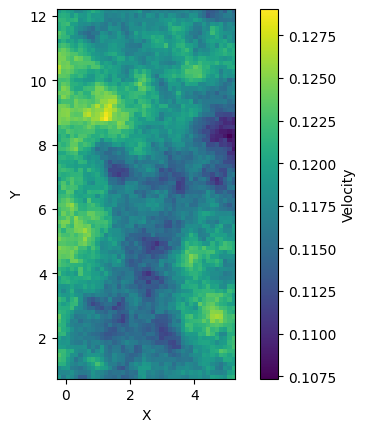

In [ ]:
from nanopinv.distribution import CholeskyPrior
from nanopinv.variance import get_distance_matrix, spherical

# x, y =
r = (
    x,
    y,
)  # Assuming x and y are defined as 1D arrays of coordinates
grid_shape = (len(x), len(y))
h = get_distance_matrix(*r)
cov = spherical(h, range_=7, partial_sill=0.00003, nugget=1e-10)

prior = CholeskyPrior(shape=grid_shape, cov=cov, m0=jnp.asarray(m0))


key = jax.random.PRNGKey(0)
samples = prior(key, num_samples=25)

plt.imshow(
    samples[5].T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(label="Velocity")
plt.xlabel("X")
plt.ylabel("Y")

In [42]:
x.shape
y.shape

(86,)